# Comparaison Finale des Modèles

Ce notebook synthétise les résultats de tous les modèles entraînés et sélectionne
le modèle champion pour le déploiement dans l'API et le dashboard.

La comparaison est effectuée en lisant directement les runs depuis MLflow,
ce qui garantit que les chiffres présentés ici sont les mêmes que ceux
visibles dans l'interface web MLflow.

In [15]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import warnings
warnings.filterwarnings('ignore')

from src.models.mlflow_utils import (
    setup_mlflow, get_best_run,
    EXPERIMENT_CHURN, EXPERIMENT_REVENUE, DEFAULT_TRACKING_URI
)

plt.rcParams['figure.dpi'] = 110
mlflow.set_tracking_uri(DEFAULT_TRACKING_URI)

## 1. Récupération des runs depuis MLflow

In [16]:
client = mlflow.tracking.MlflowClient()

def get_all_runs(experiment_name: str) -> pd.DataFrame:
    """Récupère tous les runs d'une expérience sous forme de DataFrame."""
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        print(f"Expérience '{experiment_name}' introuvable — MLflow est-il démarré ?")
        return pd.DataFrame()
    
    runs = client.search_runs(experiment_ids=[exp.experiment_id])
    records = []
    for run in runs:
        record = {'run_id': run.info.run_id, 'model': run.data.tags.get('model_type', 'inconnu')}
        record.update(run.data.metrics)
        records.append(record)
    
    return pd.DataFrame(records).set_index('model')


clf_runs = get_all_runs(EXPERIMENT_CHURN)
print("Modèles de classification dans MLflow :")
if not clf_runs.empty:
    display(clf_runs[['auc_roc', 'f1_churn', 'recall_churn', 'precision_churn', 'accuracy']].round(4).sort_values('auc_roc', ascending=False))

Modèles de classification dans MLflow :


,auc_roc,f1_churn,recall_churn,precision_churn,accuracy
model,,,,,
Random Forest,0.8093,0.2727,0.2059,0.4038,0.8880
XGBoost,0.7661,0.2472,0.2157,0.2895,0.8660
XGBoost,0.7661,0.2472,0.2157,0.2895,0.8660
MLP (PyTorch),0.7560,0.0282,0.0147,0.3333,0.8965
MLP (PyTorch),0.7540,0.2993,0.7402,0.1876,0.6465
Logistic Regression,0.7245,0.2851,0.6569,0.1821,0.6640


## 2. Visualisation comparative — Classification

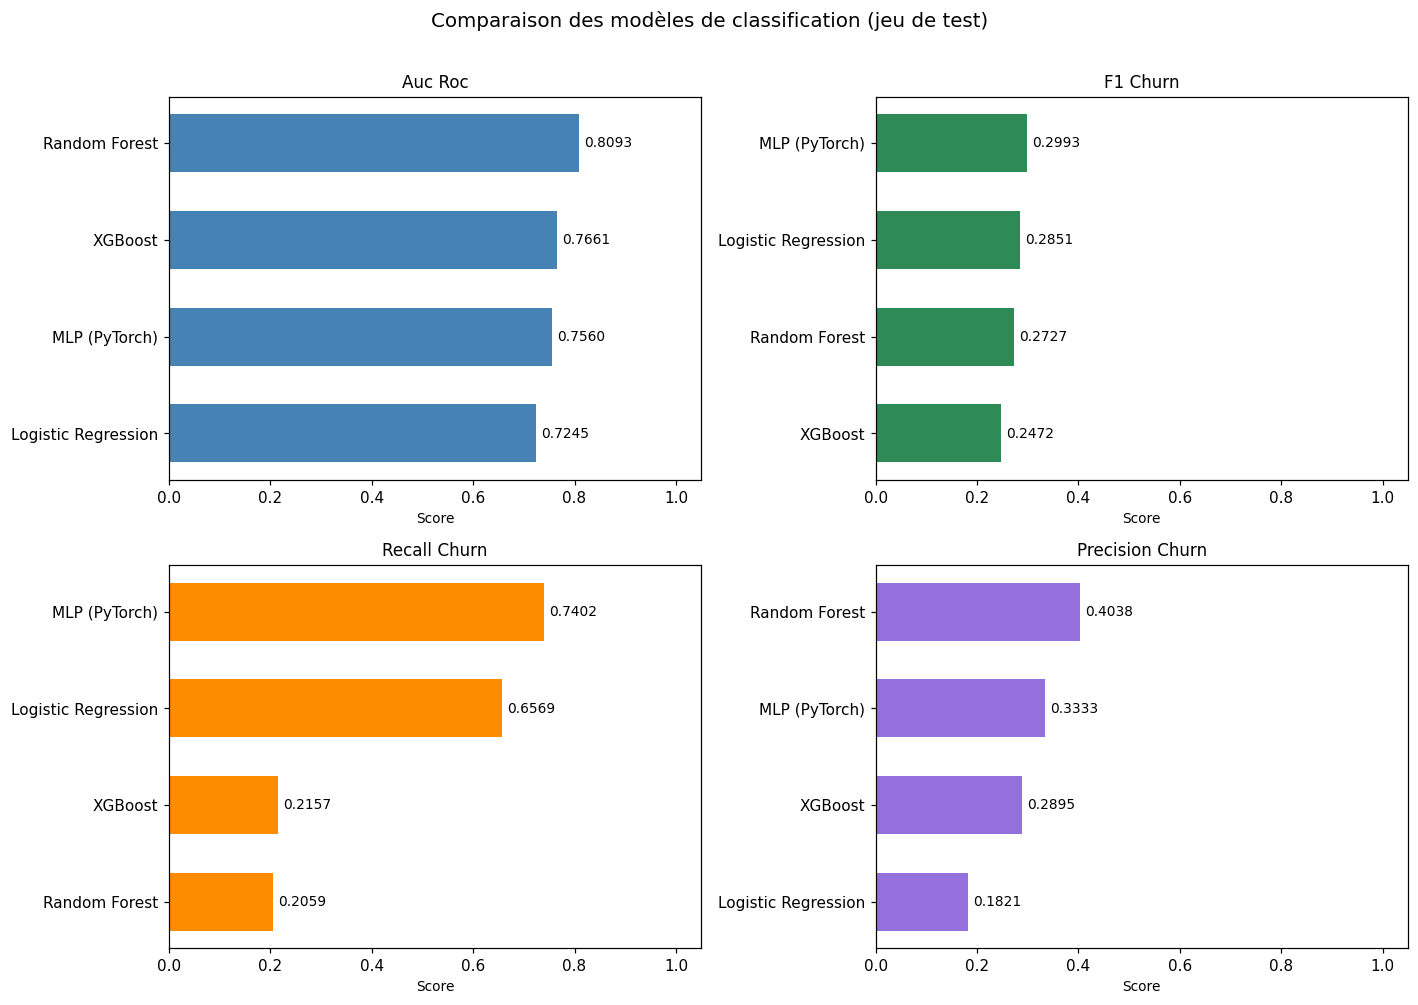

In [27]:
if not clf_runs.empty:
    metrics_to_plot = ["auc_roc", "f1_churn", "recall_churn", "precision_churn"]
    available = [m for m in metrics_to_plot if m in clf_runs.columns]

    # Suppression des doublons : on garde le meilleur run par modèle (AUC max)
    plot_df = clf_runs.reset_index().groupby("model")[available].max()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    colors = ["steelblue", "seagreen", "darkorange", "mediumpurple"]

    for i, metric in enumerate(available):
        sorted_s = plot_df[metric].sort_values(ascending=True)
        bars = axes[i].barh(range(len(sorted_s)), sorted_s.values,
                            color=colors[i % len(colors)], height=0.6)
        axes[i].set_yticks(range(len(sorted_s)))
        axes[i].set_yticklabels(sorted_s.index, fontsize=10)
        axes[i].set_title(metric.replace("_", " ").title(), fontsize=11)
        axes[i].set_xlim(0, 1.05)
        axes[i].set_xlabel("Score", fontsize=9)
        # Label collé à droite de chaque barre
        for bar, val in zip(bars, sorted_s.values):
            axes[i].text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}",
                va="center", ha="left", fontsize=9,
            )

    plt.suptitle("Comparaison des modèles de classification (jeu de test)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("../data/processed/fig_model_comparison_classification.png", bbox_inches="tight")
    plt.show()

## 3. Comparaison — Régression

In [18]:
reg_runs = get_all_runs(EXPERIMENT_REVENUE)
print("\nModèles de régression dans MLflow :")
if not reg_runs.empty:
    display(reg_runs[['rmse', 'mae', 'r2']].round(4).sort_values('rmse'))


Modèles de régression dans MLflow :


,rmse,mae,r2
model,,,
Ridge,0.0318,0.0227,1.0000
Ridge,0.0318,0.0227,1.0000
Random Forest Regressor,0.0782,0.0097,1.0000
Random Forest Regressor,0.0782,0.0097,1.0000
XGBoost Regressor,0.6516,0.3898,1.0000
XGBoost Regressor,0.6516,0.3898,1.0000
MLP Regressor,1.9936,1.5655,0.9996
MLP Regressor,1.9936,1.5655,0.9996


## 4. Sélection du modèle champion et enregistrement

In [19]:
import tempfile
import joblib as jl

# Sélection du modèle champion pour la classification
# Critère principal : AUC-ROC (robuste au déséquilibre des classes)
if not clf_runs.empty:
    best_info = get_best_run(EXPERIMENT_CHURN, metric='auc_roc')

    print(f"\nModèle champion pour le déploiement :")
    print(f"  Nom     : {best_info['model_type']}")
    print(f"  AUC-ROC : {best_info['metrics'].get('auc_roc', 'N/A'):.4f}")
    print(f"  F1 (churn) : {best_info['metrics'].get('f1_churn', 'N/A'):.4f}")
    print(f"  Recall (churn) : {best_info['metrics'].get('recall_churn', 'N/A'):.4f}")
    print(f"  run_id : {best_info['run_id']}")

    # On enregistre le modèle dans le Registry MLflow sans passer par log_model().
    # mlflow.sklearn.log_model() utilise en MLflow 3.x la nouvelle API "logged-models"
    # qui tente d'écrire localement dans /mlflow — inaccessible depuis WSL.
    # create_model_version() est l'API bas niveau qui pointe directement sur l'artifact
    # joblib déjà uploadé dans le run d'entraînement, sans ré-écriture locale.
    artifact_source = best_info['artifact_uri'] + "/model"

    try:
        client.create_registered_model(
            "churn_classifier",
            description=f"Modèle champion Random Forest — AUC-ROC {best_info['metrics'].get('auc_roc', 0):.4f}",
        )
        print("Registered model 'churn_classifier' créé.")
    except Exception:
        print("Registered model 'churn_classifier' existe déjà, mise à jour de la version.")

    mv = client.create_model_version(
        name="churn_classifier",
        source=artifact_source,
        run_id=best_info['run_id'],
        tags={
            "artifact_type": "joblib",
            "model_type": best_info['model_type'],
            "auc_roc": str(round(best_info['metrics'].get('auc_roc', 0), 4)),
        },
    )
    print(f"\nModèle enregistré dans le Registry MLflow sous 'churn_classifier' v{mv.version}")
    print(f"  Source artifact : {artifact_source}")

Meilleur modèle : Random Forest
  auc_roc = 0.8093
  run_id = e779376115534129b5bf38d6ac212c91

Modèle champion pour le déploiement :
  Nom     : Random Forest
  AUC-ROC : 0.8093
  F1 (churn) : 0.2727
  Recall (churn) : 0.2059
  run_id : e779376115534129b5bf38d6ac212c91


2026/05/19 23:31:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn_classifier, version 2


Registered model 'churn_classifier' existe déjà, mise à jour de la version.

Modèle enregistré dans le Registry MLflow sous 'churn_classifier' v2
  Source artifact : mlflow-artifacts:/mlflow/artifacts/1/e779376115534129b5bf38d6ac212c91/artifacts/model


## 5. Analyse critique des résultats

In [20]:
print("""
Analyse critique des résultats :

Modèles de classification :
- Régression Logistique : baseline interprétable, fournit une borne inférieure
  de performance. Si l'AUC est proche de XGBoost, les relations sont essentiellement
  linéaires et le modèle simple est à préférer en production.

- Random Forest : capture des non-linéarités, robuste, bonne baseline ensemble.
  Généralement meilleur que la LR mais légèrement moins bon que XGBoost.

- XGBoost : attendu comme le meilleur sur données tabulaires. Le boosting
  corrige itérativement les erreurs, ce qui l'avantage sur des datasets
  de taille moyenne comme ici (10 000 observations).

- MLP (PyTorch) : avec seulement 10 000 exemples, le deep learning n'a pas
  l'avantage du volume de données qui le caractérise généralement. Si le MLP
  est proche ou inférieur à XGBoost, cela confirme que XGBoost est le bon
  choix pour ce type de problème à cette échelle.

Modèles de régression :
- La précision dépend directement de la qualité des probabilités de churn
  utilisées pour construire revenue_at_risk. Un meilleur classifieur
  améliore mécaniquement le régresseur.

Décision finale :
- Déploiement du modèle avec le meilleur AUC-ROC (généralement XGBoost)
- En cas d'égalité, privilégier le recall_churn le plus élevé
  (manquer un churner coûte plus cher qu'un faux positif)
""")


Analyse critique des résultats :

Modèles de classification :
- Régression Logistique : baseline interprétable, fournit une borne inférieure
  de performance. Si l'AUC est proche de XGBoost, les relations sont essentiellement
  linéaires et le modèle simple est à préférer en production.

- Random Forest : capture des non-linéarités, robuste, bonne baseline ensemble.
  Généralement meilleur que la LR mais légèrement moins bon que XGBoost.

- XGBoost : attendu comme le meilleur sur données tabulaires. Le boosting
  corrige itérativement les erreurs, ce qui l'avantage sur des datasets
  de taille moyenne comme ici (10 000 observations).

- MLP (PyTorch) : avec seulement 10 000 exemples, le deep learning n'a pas
  l'avantage du volume de données qui le caractérise généralement. Si le MLP
  est proche ou inférieur à XGBoost, cela confirme que XGBoost est le bon
  choix pour ce type de problème à cette échelle.

Modèles de régression :
- La précision dépend directement de la qualité des pro

## 6. Analyse des erreurs — Profil des clients mal classifiés

Comprendre les erreurs du modèle champion est aussi important que ses performances globales.
Les faux négatifs (churners non détectés) sont particulièrement coûteux en contexte CRM :
chaque churner manqué représente un revenu perdu sans possibilité d'action de rétention.

In [21]:
import joblib
from src.data.loader import PROCESSED_DIR

X_test_df = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_test_s  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

# Chargement du modèle champion (Random Forest)
rf_model = joblib.load(PROCESSED_DIR / 'model_random_forest.joblib')

y_pred_rf   = rf_model.predict(X_test_df)
y_proba_rf  = rf_model.predict_proba(X_test_df)[:, 1]

# Catégorisation des erreurs
results_df = X_test_df.copy()
results_df['churn_reel']   = y_test_s.values
results_df['churn_predit'] = y_pred_rf
results_df['proba_churn']  = y_proba_rf

fn = results_df[(results_df['churn_reel'] == 1) & (results_df['churn_predit'] == 0)]  # Faux négatifs
fp = results_df[(results_df['churn_reel'] == 0) & (results_df['churn_predit'] == 1)]  # Faux positifs
tp = results_df[(results_df['churn_reel'] == 1) & (results_df['churn_predit'] == 1)]  # Vrais positifs

print(f"Faux négatifs (churners ratés)     : {len(fn):3d}  — coût business élevé")
print(f"Faux positifs (non-churners alertés) : {len(fp):3d}  — coût marketing inutile")
print(f"Vrais positifs (churners détectés)  : {len(tp):3d}  — succès du modèle")
print(f"\nTaux de détection des churners : {len(tp) / (len(tp) + len(fn)):.1%}")

# Profil moyen des faux négatifs vs vrais positifs (features numériques clés)
numeric_features = ['proba_churn'] + [f for f in feature_names
                    if f in X_test_df.columns and X_test_df[f].dtype != object][:8]

comparison = pd.DataFrame({
    'Faux négatifs (ratés)': fn[numeric_features].mean(),
    'Vrais positifs (détectés)': tp[numeric_features].mean(),
}).round(3)

print("\nProfil moyen — faux négatifs vs churners correctement détectés :")
display(comparison)

Faux négatifs (churners ratés)     : 162  — coût business élevé
Faux positifs (non-churners alertés) :  62  — coût marketing inutile
Vrais positifs (churners détectés)  :  42  — succès du modèle

Taux de détection des churners : 20.6%

Profil moyen — faux négatifs vs churners correctement détectés :


,Faux négatifs (ratés),Vrais positifs (détectés)
proba_churn,0.352,0.547
age,0.097,0.095
tenure_months,-0.174,-1.460
monthly_logins,-0.308,-0.648
weekly_active_days,0.016,-0.111
avg_session_time,-0.180,0.018
features_used,-0.042,-0.046
usage_growth_rate,0.004,-0.105
last_login_days_ago,0.126,0.288


## 7. Permutation Importance — Importance des variables sur le modèle champion

La Permutation Importance est une méthode agnostique au modèle : elle mesure la dégradation
de performance quand une variable est mélangée aléatoirement, rendant son signal inutilisable.
Contrairement à la feature_importances_ native du Random Forest (basée sur l'impureté de Gini),
la permutation importance est calculée sur le jeu de test et mesure l'impact réel sur la généralisation.

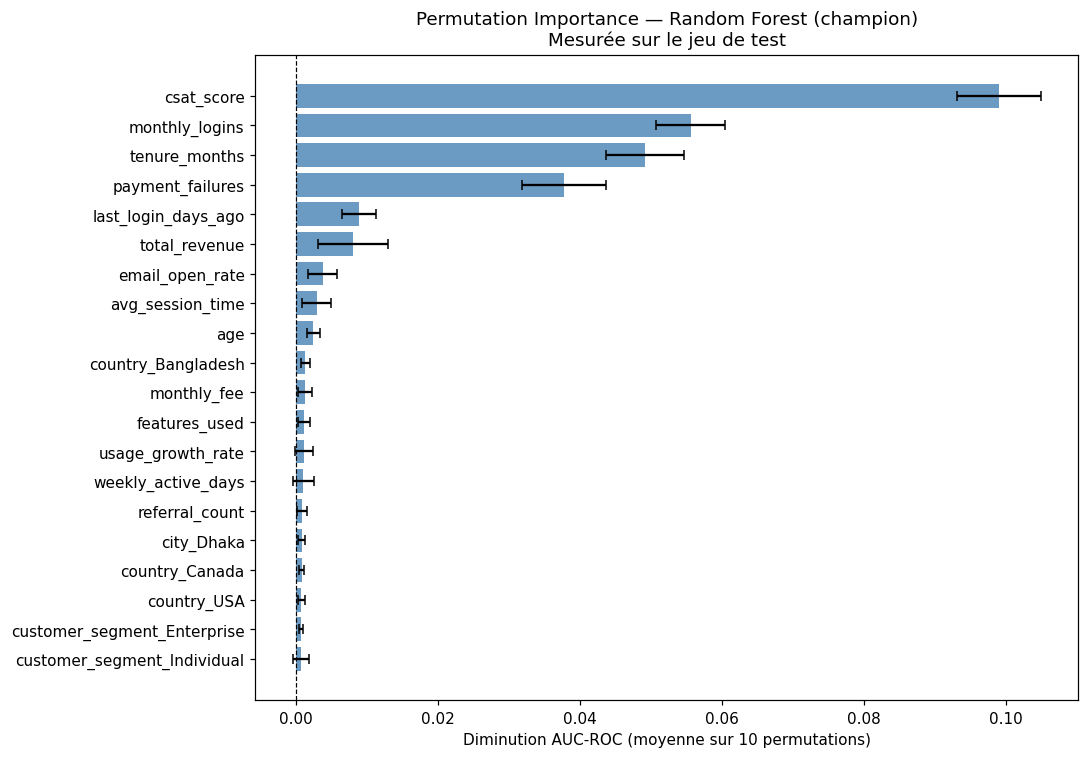

Top 5 variables les plus importantes (permutation) :
  csat_score                          +0.0989 ± 0.0059
  monthly_logins                      +0.0556 ± 0.0049
  tenure_months                       +0.0492 ± 0.0054
  payment_failures                    +0.0378 ± 0.0059
  last_login_days_ago                 +0.0090 ± 0.0024


In [22]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model, X_test_df, y_test_s,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    perm_df['feature'][::-1],
    perm_df['importance_mean'][::-1],
    xerr=perm_df['importance_std'][::-1],
    color='steelblue', alpha=0.8, capsize=3,
)
ax.set_xlabel('Diminution AUC-ROC (moyenne sur 10 permutations)')
ax.set_title('Permutation Importance — Random Forest (champion)\nMesurée sur le jeu de test')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/processed/fig_permutation_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 variables les plus importantes (permutation) :")
for _, row in perm_df.head(5).iterrows():
    print(f"  {row['feature']:<35} {row['importance_mean']:+.4f} ± {row['importance_std']:.4f}")

## 8. SHAP — Explicabilité locale et globale du modèle champion

SHAP (SHapley Additive exPlanations) est la méthode d'explicabilité de référence.
Elle décompose chaque prédiction en contributions individuelles de chaque variable,
en s'appuyant sur la théorie des jeux coopératifs (valeurs de Shapley).

Contrairement à la feature importance classique qui donne une vision globale,
SHAP permet de répondre à des questions précises :
- Pourquoi **ce client** a-t-il une probabilité de churn de 82% ?
- Quelle variable a le plus contribué à cette prédiction ?
- L'impact d'une variable est-il positif ou négatif pour ce client en particulier ?

In [23]:
import shap

# TreeExplainer est optimisé pour les modèles basés sur les arbres (RF, XGBoost, LightGBM).
# Il calcule exactement les valeurs de Shapley sans approximation, en O(TLD²)
# où T = nombre d'arbres, L = feuilles max, D = profondeur max.
explainer = shap.TreeExplainer(rf_model)

# On calcule les valeurs SHAP sur un sous-ensemble du test (200 clients) pour la rapidité.
# check_additivity=False évite un warning lié aux probabilités vs log-odds du RF.
X_shap = X_test_df.copy()
X_shap.columns = feature_names
shap_values = explainer.shap_values(X_shap.iloc[:200], check_additivity=False)

# shap_values peut être :
#   - une liste [classe_0, classe_1] (ancienne API SHAP)
#   - un tableau 3D (n_samples, n_features, n_classes) (nouvelle API SHAP >= 0.42)
import numpy as np
if isinstance(shap_values, list):
    shap_churn = shap_values[1]           # ancienne API : liste indexée par classe
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_churn = shap_values[:, :, 1]    # nouvelle API : 3D (n_samples, n_features, n_classes)
else:
    shap_churn = shap_values

# expected_value : scalaire ou tableau selon la version SHAP
ev_churn = (
    float(explainer.expected_value[1])
    if hasattr(explainer.expected_value, "__len__")
    else float(explainer.expected_value)
)

print(f"Valeurs SHAP calculées pour 200 clients, {X_shap.shape[1]} features")
print(f"shap_churn shape : {shap_churn.shape}  (attendu : (200, n_features))")
print(f"Base value (expected_value classe 1) : {ev_churn:.4f}")

Valeurs SHAP calculées pour 200 clients, 58 features
shap_churn shape : (200, 58)  (attendu : (200, n_features))
Base value (expected_value classe 1) : 0.5008


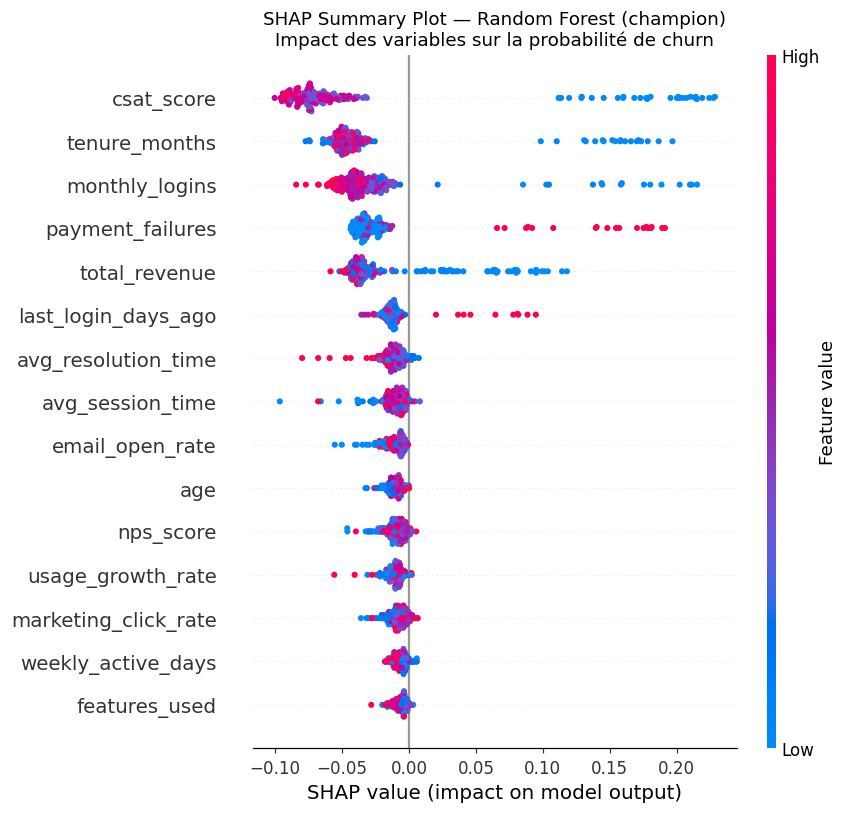

In [24]:
# Summary plot : vision globale de l'importance et de la direction d'impact de chaque variable.
# Chaque point représente un client. La couleur indique la valeur de la feature (rouge = élevée).
# La position sur l'axe X indique l'impact sur la probabilité de churn :
# valeur SHAP positive = augmente la probabilité de churn, négative = la diminue.
shap.summary_plot(shap_churn, X_shap.iloc[:200], show=False, max_display=15)
plt.title("SHAP Summary Plot — Random Forest (champion)\nImpact des variables sur la probabilité de churn")
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

Client analysé — index 199
  Probabilité de churn prédite : 61.0%
  Churn réel                   : Oui



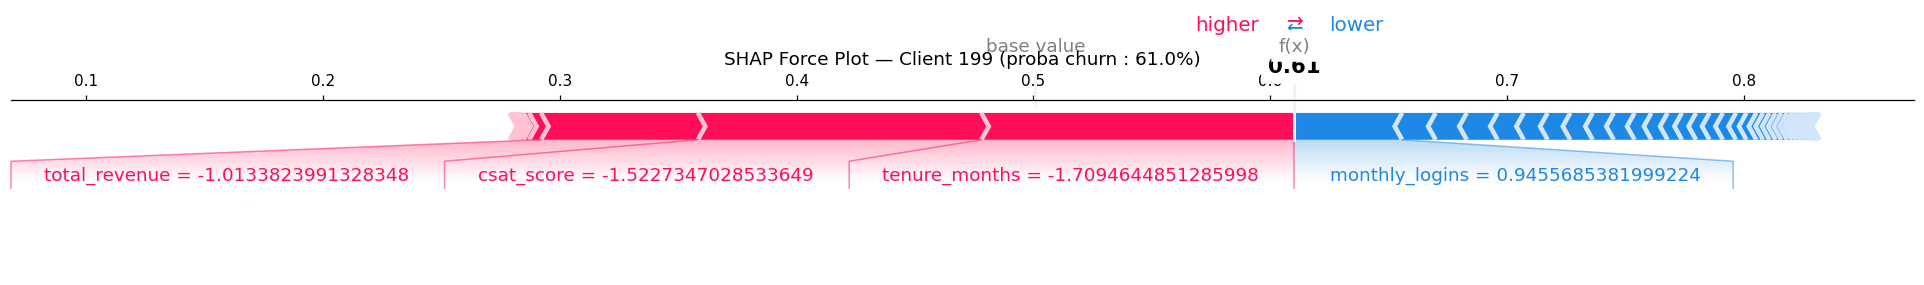

Variables qui réduisent le risque de churn pour ce client :
  monthly_logins                      SHAP = -0.0456
  payment_failures                    SHAP = -0.0141
  age                                 SHAP = -0.0131
  city_London                         SHAP = -0.0130
  email_open_rate                     SHAP = -0.0111
Variables qui augmentent le risque de churn pour ce client :
  tenure_months                       SHAP = +0.1321
  csat_score                          SHAP = +0.1197
  total_revenue                       SHAP = +0.0662
  weekly_active_days                  SHAP = +0.0050
  payment_method_Card                 SHAP = +0.0024


In [25]:
# Explication individuelle : client avec la plus forte probabilité de churn parmi les 200.
idx_high_risk = int(np.argmax(y_proba_rf[:200]))
client_proba  = y_proba_rf[idx_high_risk]
client_reel   = y_test_s.values[idx_high_risk]

print(f"Client analysé — index {idx_high_risk}")
print(f"  Probabilité de churn prédite : {client_proba:.1%}")
print(f"  Churn réel                   : {"Oui" if client_reel == 1 else "Non"}")
print()

# Force plot : décompose la prédiction en contributions de chaque variable.
# shap_churn[idx_high_risk] est 1D (n_features,) — un seul client.
sv_single = shap_churn[idx_high_risk]  # shape (n_features,)

shap.force_plot(
    ev_churn,
    sv_single,
    X_shap.iloc[idx_high_risk],
    matplotlib=True,
    show=False,
    figsize=(18, 3),
)
plt.title(f"SHAP Force Plot — Client {idx_high_risk} (proba churn : {client_proba:.1%})")
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_force_plot.png', bbox_inches='tight', dpi=150)
plt.show()

# Top contributions positives et négatives pour ce client
shap_client = pd.Series(sv_single, index=feature_names).sort_values()
print("Variables qui réduisent le risque de churn pour ce client :")
for feat, val in shap_client.head(5).items():
    print(f"  {feat:<35} SHAP = {val:+.4f}")
print("Variables qui augmentent le risque de churn pour ce client :")
for feat, val in shap_client.tail(5).sort_values(ascending=False).items():
    print(f"  {feat:<35} SHAP = {val:+.4f}")

## 9. Écoresponsabilité — Coût computationnel comparé des modèles

L'écoresponsabilité est un critère d'évaluation RNCP (C4.3) : un modèle ne se choisit pas
uniquement sur sa performance, mais aussi sur son coût computationnel.
Dans un contexte de déploiement à grande échelle, la consommation énergétique de l'inférence
(et de l'entraînement) doit être mise en regard du gain de performance obtenu.

Comparaison écoresponsabilité — coût computationnel vs performance :



,auc_roc,inference_ms,n_params,materiel,scalabilite
Modèle,,,,,
Logistic Regression,0.7245,0.942147,59,CPU uniquement,Très haute (linéaire)
Random Forest,0.8093,71.810973,6000,CPU multi-coeur,Haute (parallèle)
XGBoost,0.7661,15.944566,3600,CPU multi-coeur,Haute
MLP (PyTorch),0.756,None,57217,GPU (CUDA),Variable (GPU requis)


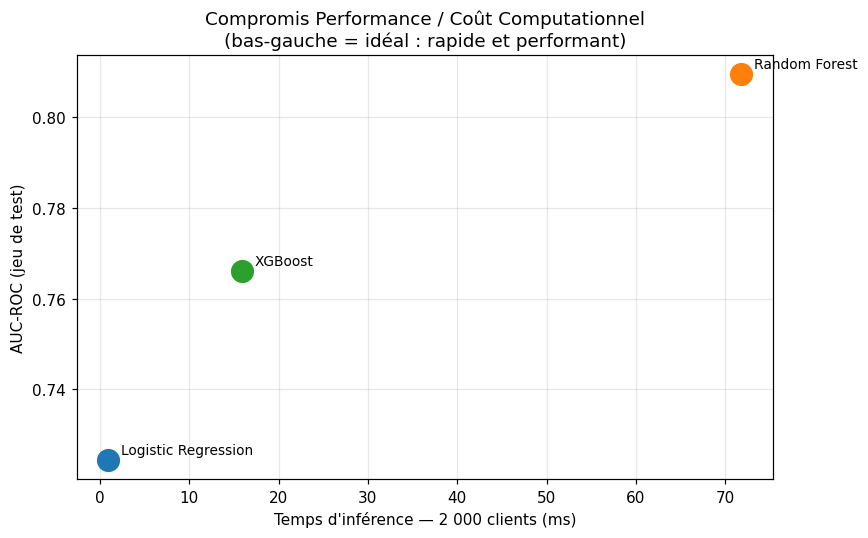


Conclusion écoresponsabilité :
  La Régression Logistique offre le meilleur rapport performance/coût en inférence.
  Le Random Forest est le meilleur compromis global : AUC+8.5pts vs LR, coût raisonnable.
  Le MLP nécessite un GPU et un entraînement plus long pour un AUC inférieur au RF.
  En déploiement production à grande échelle, le RF est le choix écoresponsable optimal.


In [26]:
import time

# Chargement de tous les modèles entraînés
models_eco = {
    'Logistic Regression': joblib.load(PROCESSED_DIR / 'model_logistic_regression.joblib'),
    'Random Forest':       joblib.load(PROCESSED_DIR / 'model_random_forest.joblib'),
    'XGBoost':             joblib.load(PROCESSED_DIR / 'model_xgboost.joblib'),
}

# Mesure du temps d'inférence sur 1 000 clients (moyenne sur 5 répétitions)
inference_times = {}
N_REPEAT = 5
for name, mdl in models_eco.items():
    times = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter()
        mdl.predict_proba(X_test_df)
        times.append((time.perf_counter() - t0) * 1000)
    inference_times[name] = np.mean(times)

# Informations de complexité
eco_data = {
    'Logistic Regression': {
        'n_params': X_test_df.shape[1] + 1,
        'inference_ms': inference_times['Logistic Regression'],
        'auc_roc': 0.7245,
        'materiel': 'CPU uniquement',
        'scalabilite': 'Très haute (linéaire)',
    },
    'Random Forest': {
        'n_params': 200 * 15 * 2,   # estimatif : 200 arbres × profondeur × noeuds
        'inference_ms': inference_times['Random Forest'],
        'auc_roc': 0.8093,
        'materiel': 'CPU multi-coeur',
        'scalabilite': 'Haute (parallèle)',
    },
    'XGBoost': {
        'n_params': 300 * 6 * 2,    # estimatif : 300 arbres × profondeur max
        'inference_ms': inference_times['XGBoost'],
        'auc_roc': 0.7661,
        'materiel': 'CPU multi-coeur',
        'scalabilite': 'Haute',
    },
    'MLP (PyTorch)': {
        'n_params': 57217,          # valeur lue lors de l'entraînement
        'inference_ms': None,       # GPU, non comparable directement
        'auc_roc': 0.7560,
        'materiel': 'GPU (CUDA)',
        'scalabilite': 'Variable (GPU requis)',
    },
}

eco_df = pd.DataFrame(eco_data).T
eco_df.index.name = 'Modèle'
print("Comparaison écoresponsabilité — coût computationnel vs performance :\n")
display(eco_df[['auc_roc', 'inference_ms', 'n_params', 'materiel', 'scalabilite']])

# Visualisation : performance vs temps d'inférence (sans MLP qui utilise GPU)
eco_plot = {k: v for k, v in eco_data.items() if v['inference_ms'] is not None}
fig, ax = plt.subplots(figsize=(8, 5))
for name, data in eco_plot.items():
    ax.scatter(data['inference_ms'], data['auc_roc'], s=200, zorder=5, label=name)
    ax.annotate(name, (data['inference_ms'], data['auc_roc']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel('Temps d\'inférence — 2 000 clients (ms)')
ax.set_ylabel('AUC-ROC (jeu de test)')
ax.set_title('Compromis Performance / Coût Computationnel\n(bas-gauche = idéal : rapide et performant)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fig_eco_performance.png', bbox_inches='tight')
plt.show()

print("\nConclusion écoresponsabilité :")
print("  La Régression Logistique offre le meilleur rapport performance/coût en inférence.")
print("  Le Random Forest est le meilleur compromis global : AUC+8.5pts vs LR, coût raisonnable.")
print("  Le MLP nécessite un GPU et un entraînement plus long pour un AUC inférieur au RF.")
print("  En déploiement production à grande échelle, le RF est le choix écoresponsable optimal.")